In [1]:
import os
import glob
import json
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import h5py
from vip_slap2_analysis.glutamate.summary import GlutamateSummary
from vip_slap2_analysis.utils.utils import save_figure
from skimage import measure
import seaborn as sns

from PNW_cmap import PNW_cmap
sns.set_style('white')
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
%matplotlib notebook

In [4]:
basepath = r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics"
savepath = r"C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Data_Club\April2026\figures"
summary_path = glob.glob(os.path.join(basepath,'**summary.xlsx'))[0]
summary_df = pd.read_excel(summary_path,sheet_name='subjects')
session_df = pd.read_excel(summary_path,sheet_name='sessions')

In [5]:
target_mouse = 803496

session_paths = session_df[session_df['subject_id']==target_mouse]['session_dir'].values
summary_datapaths = [glob.glob(os.path.join(p,'**','source_extraction','ExperimentSummary','SummaryLoCo**.mat'),recursive=True) for p in session_paths]
summary_datapaths = [x for l in summary_datapaths for x in l]
summary_datapaths

datapath = summary_datapaths[3]
datapath

'\\\\allen\\aind\\scratch\\ophys\\Andrew\\VIP_synaptic_dynamics\\iGluSnFR4f\\803496\\2025-07-30_803496\\803496_2025-07-30_10-05-23_slap2_2026-01-20_19-56-29\\source_extraction\\ExperimentSummary\\SummaryLoCo-260120-091441.mat'

In [6]:
gs = GlutamateSummary(datapath, keep_open=True)
valid_trials_dmd1 = gs.valid_trials[0]
valid_trials_dmd2 = gs.valid_trials[1]
print(gs.n_synapses)          # list per DMD
print(gs.valid_trials[1])     # trials for DMD1

[104, 67]
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62]


In [23]:
dmd1_traces = gs.get_traces(dmd=1,trial=5).T

In [24]:
dmd1_footprints = gs.mean_footprints_across_trials(dmd=1)

In [25]:
np.shape(dmd1_footprints)

(104, 961, 652)

In [26]:
coords = gs.footprint_centroids(dmd1_footprints,weighted=True)

<IPython.core.display.Javascript object>


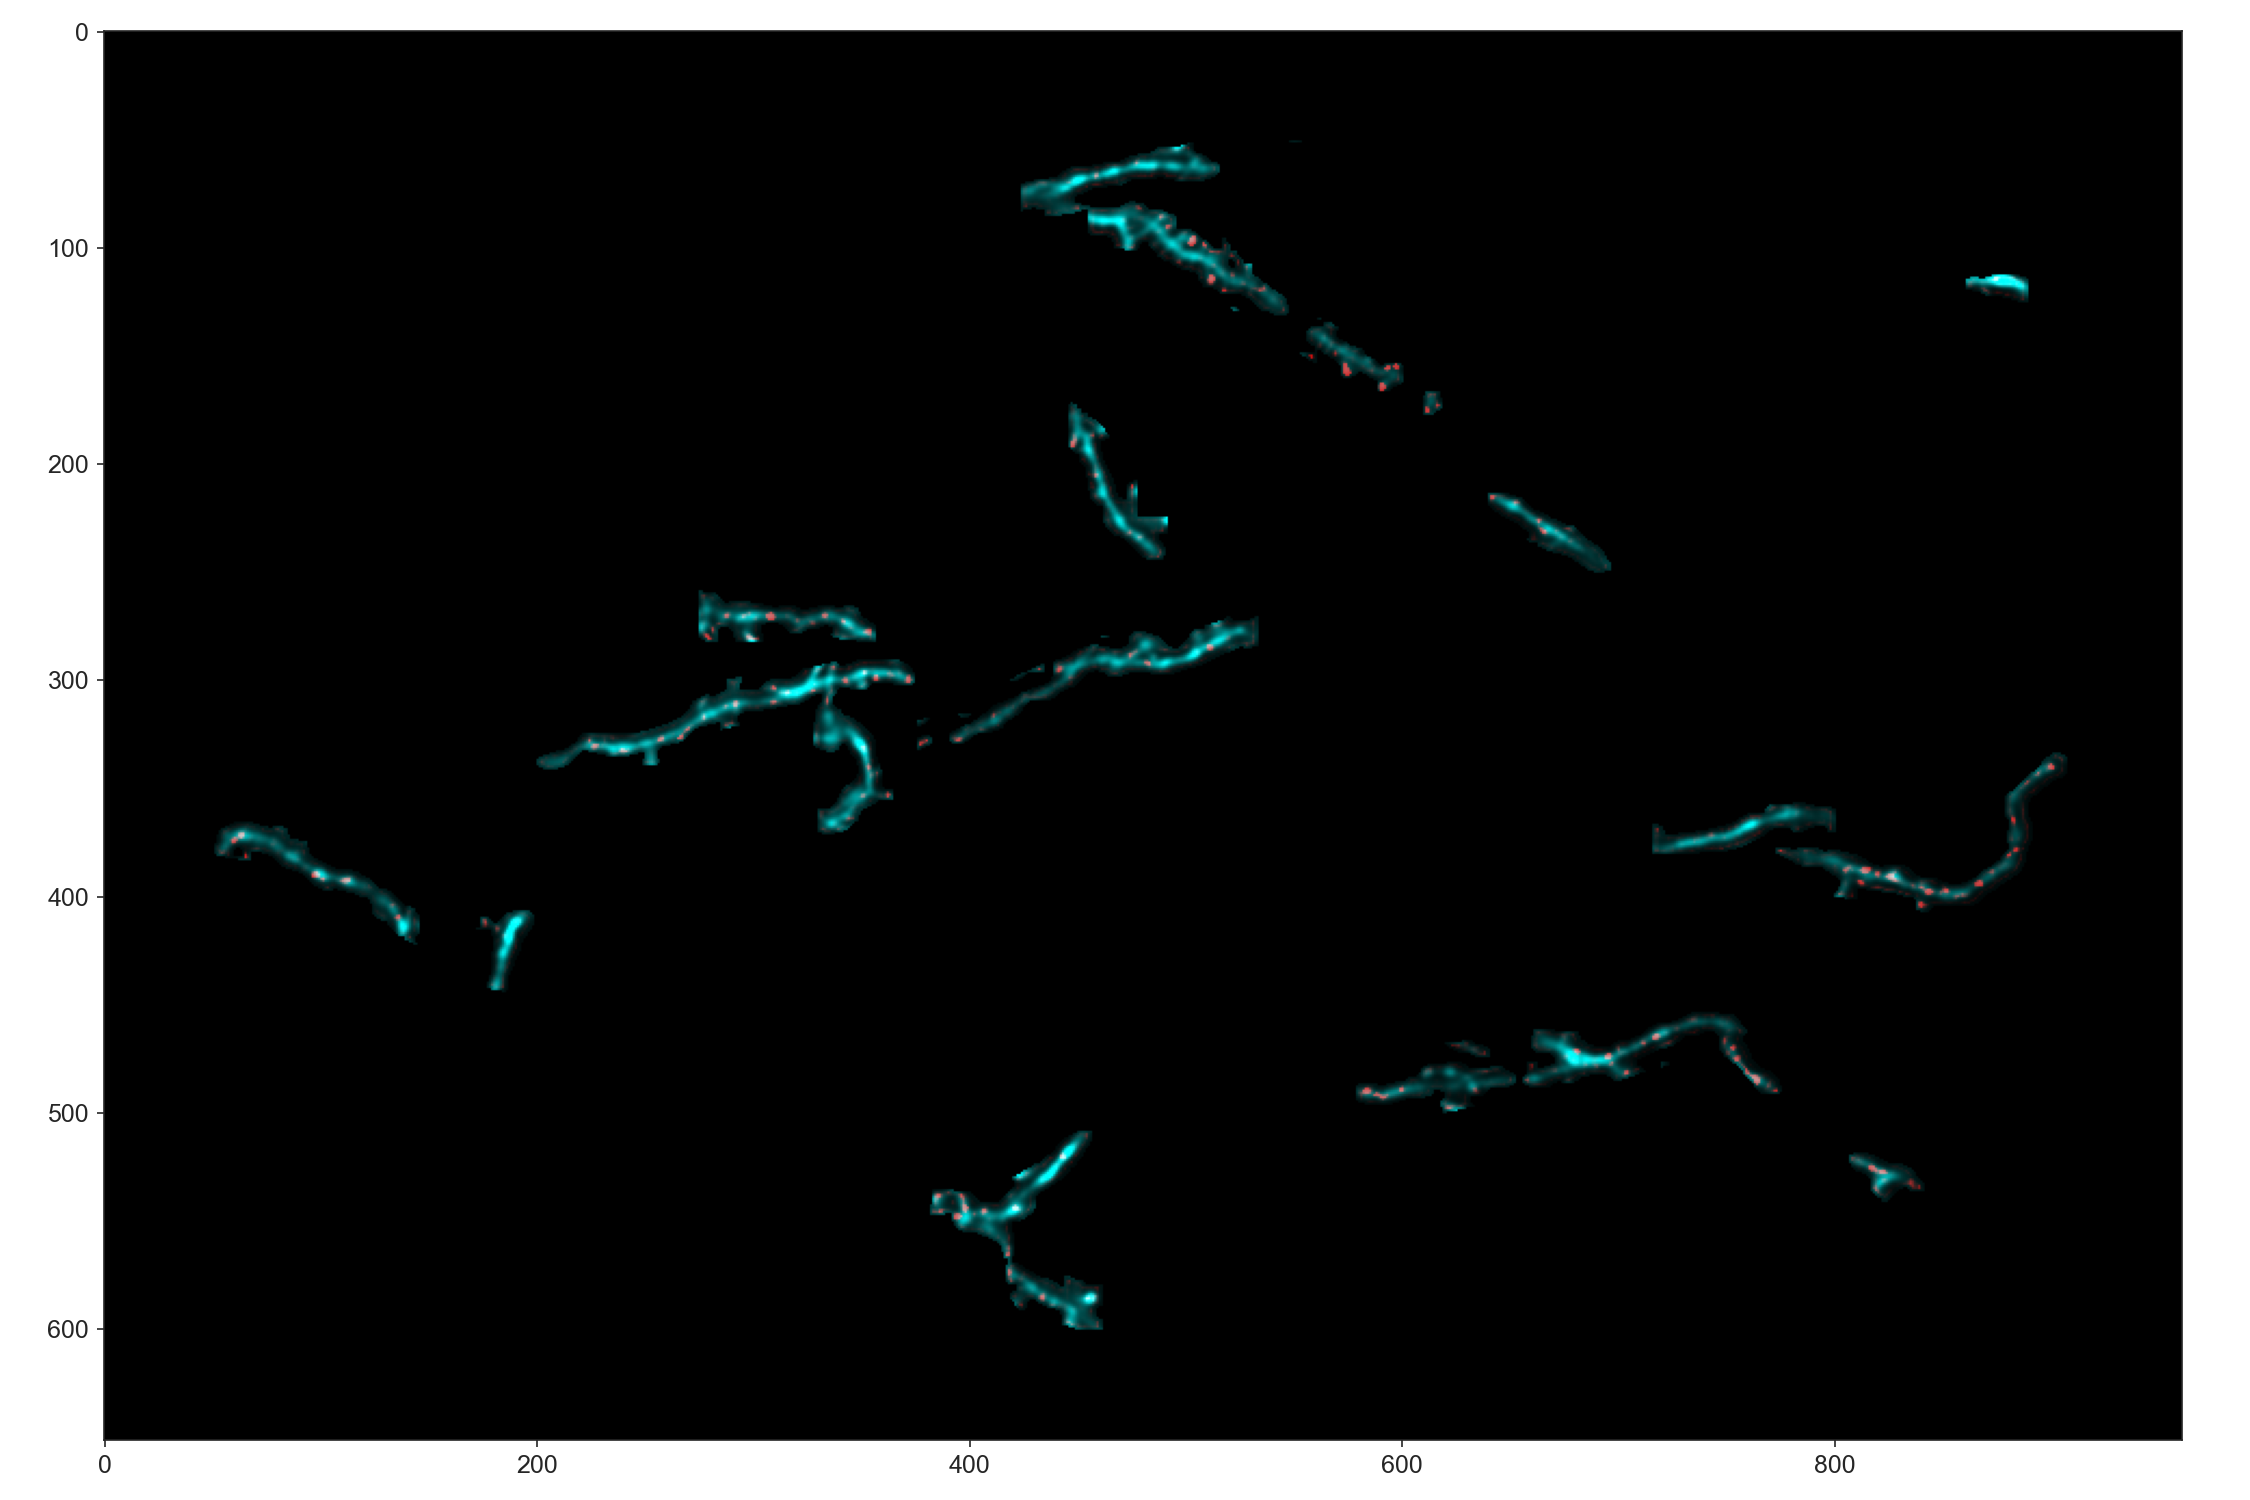

In [27]:
im = gs.overlay_summary_images(
    mean_channel="glutamate",
    dmds=[1],
    q_mean=0.99,
    q_act=0.9995,
    use_shared_scale=True,
    mean_gamma=1,
    act_gamma=1.75,
    act_rgb = (1.0,0.0,0.0),
    alpha_act=0.8,
    alpha_mean=1,
    mean_max_val=50.0,
    act_max_val=5.0,
    mask_to_selpix=False,
    
)

fig,ax=plt.subplots(figsize=(15,10))
ax.tick_params(axis='x',which='major',reset=True,top=False,labelsize=12)
ax.tick_params(axis='y',which='major',reset=True,right=False,labelsize=12)
ax.imshow(np.array(im[0]).transpose(0,1,2),cmap='magma')
# ax.imshow(np.array(im[1]).transpose(1,0,2),cmap='viridis')

fig.tight_layout()
filen = 'mean_activity_overlay_dmd1'
save_figure(fig,os.path.join(savepath,filen),formats=['.pdf'],dpi=300)

<IPython.core.display.Javascript object>


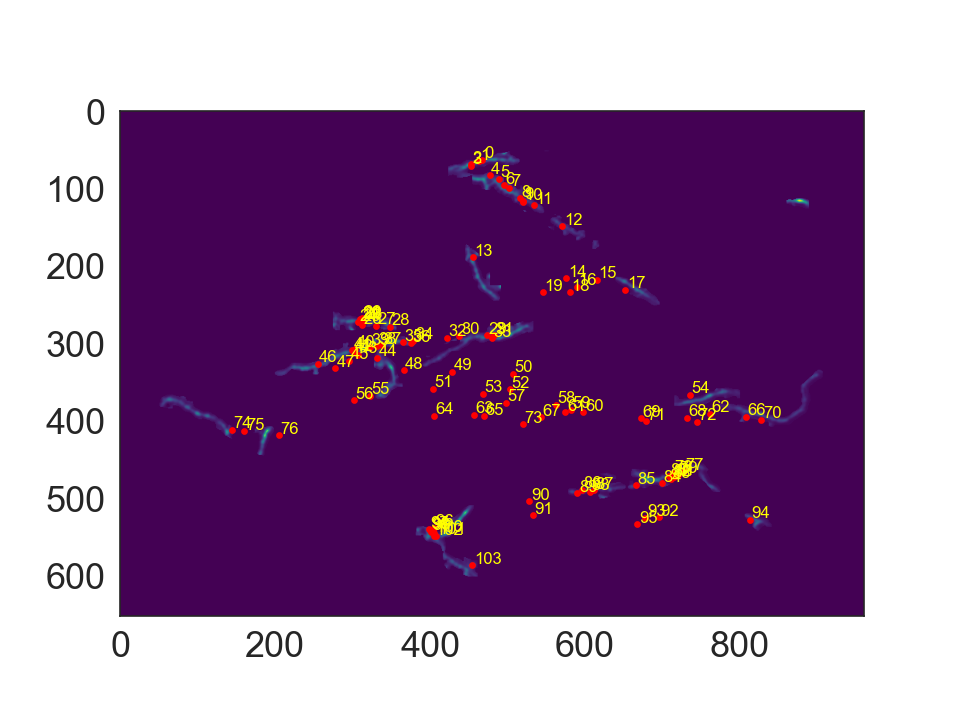

In [28]:
fig,ax=plt.subplots()

im = gs.get_summary_image(dmd=1, image_type='meanIM')
im = np.nan_to_num(im)
ax.imshow(im, cmap='viridis')

ax.scatter(coords[:, 0], coords[:, 1], color='r', s=5)

for i, (y, x) in enumerate(coords):
    if np.isnan(y) or np.isnan(x):
        continue
    ax.text(
        y + 2, x + 2, str(i),
        color="yellow",
        fontsize=8,
        ha="left",
        va="bottom"
    )

In [16]:
np.shape(im)

(1, 652, 961, 3)

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))
axes = axes.ravel()

test_idx = [0, 5, 10, 20, 40, 60]

for ax, i in zip(axes, test_idx):
    fp = dmd1_footprints[i]
    y, x = coords[i]

    ax.imshow(np.nan_to_num(fp), cmap="viridis")
    ax.scatter(x, y, c="r", s=20)
    ax.set_title(f"syn {i}")
    ax.set_xlim(max(0, x - 20), min(fp.shape[1], x + 20))
    ax.set_ylim(min(fp.shape[0], y + 20), max(0, y - 20))  # keep image orientation

In [ ]:
fig,ax = plt.subplots(figsize=(6,2))

ax.tick_params(axis='x',which='major',reset=True,top=False,labelsize=12)
ax.tick_params(axis='y',which='major',reset=True,right=False,labelsize=12)

offset=50

fs = 200

synapse_idx = [66,70]

cl,cmap,cp = PNW_cmap.get_PNW_cmap('Sunset',n_colors=len(synapse_idx))

for i,syn in enumerate(synapse_idx):
    trace = dmd1_traces[syn,]
    time = np.linspace(0,len(trace)/fs,len(trace))
    ax.plot(time,trace+i*offset,color=cp[i])

    

fig.tight_layout()

In [ ]:
im = gs.get_summary_image(dmd=2,image_type='meanIM')[:]

# 1. Make a binary mask
mask = np.isfinite(im).astype(float)

# Optional: remove tiny junk objects if needed
# from skimage.morphology import remove_small_objects
# mask = remove_small_objects(mask.astype(bool), min_size=20).astype(float)

# 2. Extract contour lines at the mask boundary
contours = measure.find_contours(mask, level=0.5)

# 3. Plot contours only
fig, ax = plt.subplots(figsize=(8, 6))

for contour in contours:
    # skimage returns coordinates as (row, col) = (y, x)
    y = contour[:, 0]
    x = contour[:, 1]
    ax.plot(x, y, color='black', linewidth=1)

# Match image coordinates
ax.set_aspect('equal')
ax.invert_yaxis()
ax.axis('off')

# 4. Save as vector PDF

plt.show()
filen = 'ROIs_dmd2'
save_figure(fig,os.path.join(savepath,filen),formats=['.pdf'],dpi=300)

In [ ]:
valid_trials = [valid_trials_dmd1,valid_trials_dmd2]

dmd = 1

n_somas = gs.get_user_roi_traces(dmd=dmd+1,trial=valid_trials[dmd][0]).shape[0]

soma_signals = [ [] for _ in range(n_somas) ]

for trial in gs.valid_trials[dmd]:
    traces = gs.get_user_roi_traces(dmd=dmd+1,trial=trial)
    for s in range(n_somas):
        soma_signals[s].append(traces[s,1,:])    # (n_samples,)
soma_signals = [np.concatenate(chunks, axis=0) for chunks in soma_signals]

In [ ]:
time = np.linspace(0,len(soma_signals[0])/200,len(soma_signals[0]))
cl,cmap,cp = PNW_cmap.get_PNW_cmap('Sunset',n_colors=10)
fig,ax=plt.subplots()

ax.tick_params(axis='x',which='major',reset=True,top=False,labelsize=12)
ax.tick_params(axis='y',which='major',reset=True,right=False,labelsize=12)

cl, cmap, cp = PNW_cmap.get_PNW_cmap('Sailboat', n_colors=len(soma_signals))

for i,soma in enumerate(soma_signals):
    ax.plot(time,soma,color=cl[i])
ax.set_ylabel('Fluorescence (F)')
ax.set_xlabel('Time (s)')

# ax.set_title('Soma 1 -- preprocessing')

fig.tight_layout()

In [ ]:
gs.metadata['analyzeHz']

In [ ]:
out = gs.get_processed_soma_ca_all_trials(
    dmd=dmd+1,
    trace_type="Fsvd",
    fs_hz=gs.metadata["analyzeHz"],
    pad_to="max_valid",
    include_invalid=True,

    motion_correct=True,
    motion_regress_on="dF",
    motion_ridge=1e-2,
    motion_use_fields=("onlineXshift","onlineYshift","onlineZshift",
                       "motionDSr","motionDSc"
                      ),
    use_glu_as_motion_regressor=True,

    baseline_method="hull",
    denoise_window_s=2.0,   # was 1.0
    hull_window_s=90.0,     # was 30.0  (this is the big one)
    f0_floor_frac=0.05,     # was 0.02  (guardrail)

    mask_artifacts=True,
    std_factor=20.0,
    nan_pad=10,
    unmix=True,
    hp_window_s=0.5,
    ridge=1e-6,
)

In [ ]:
# Key outputs (trial, roi, time)
dff = out["dff"]         # (n_trials, n_rois, Tpad)
ca_mc = out["ca_mc"]     # motion-regressed Ca
beta_unmix = out["beta_unmix"]

In [ ]:
roi = 0
tr = 1
base = out["baseline"][tr-1, roi, :]
print("eps clamp fraction:", (base <= 1.0001e-6).mean())
print("baseline median:", np.nanmedian(base))

print("dff shape:", dff.shape)
print("fraction NaN (trial0, roi0):", (np.isnan(dff[0,0]).mean()))

In [ ]:
# Concatenate across ALL trials (invalid trials contribute NaNs)
dff_cat = np.concatenate([dff[tr, roi, :] for tr in range(gs.n_trials)], axis=0)

print("dF/F concat len:", dff_cat.size)
print("nan frac:", np.isnan(dff_cat).mean())
print('')

baseline_cat = np.concatenate([out['baseline'][tr, roi, :] for tr in range(gs.n_trials)], axis=0)

print("baseline concat len:", baseline_cat.size)
print("nan frac:", np.isnan(baseline_cat).mean())
print('')

df_mc_r_cat = np.concatenate([out['ca_mc'][tr, roi, :] for tr in range(gs.n_trials)], axis=0)

print("mc_r concat len:", df_mc_r_cat.size)
print("nan frac:", np.isnan(df_mc_r_cat).mean())
print('')

In [ ]:
fig,ax = plt.subplots(3,sharex=True)

time = np.linspace(0,len(dff_cat)/200,len(dff_cat))

titles = ['Baseline F0','dF Motion Corrected','\u0394F/F0']
signals = [baseline_cat,df_mc_r_cat,dff_cat]

for i,axis in enumerate(ax.flatten()):
    axis.tick_params(axis='x',which='major',reset=True,top=False,labelsize=12)
    axis.tick_params(axis='y',which='major',reset=True,right=False,labelsize=12)
    
    axis.plot(time,signals[i])
    
    axis.set_title(titles[i])

ax[1].set_ylabel('Signal')
ax[2].set_xlabel('Time (s)')
# ax[2].set_ylim(-3,3)
fig.tight_layout()

In [ ]:
n_rois = np.shape(dff)[1]
offset = 1               # you were using i/2
fs = 200                       # Hz

cl, cmap, cp = PNW_cmap.get_PNW_cmap('Sailboat', n_colors=n_rois)

fig, ax = plt.subplots(figsize=(6, 4))
sns.despine()

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

tw = [0,1800]

for i in range(n_rois):
    # concatenate across trials for ROI i  -> (samples_total,)
    dff_ = np.concatenate([dff[tr, i] for tr in range(gs.n_trials)], axis=0)

    # If all NaN, skip plotting (but we’ll still label its tick below)
    if np.all(np.isnan(dff_)):
        continue

    time = np.arange(dff_.size) / fs

    y = dff_ + i * offset
    ax.plot(time[(time<=tw[1])&(time>tw[0])], y[(time<=tw[1])&(time>tw[0])], color=cp[i], zorder=10 - i,lw=2)

    y_smooth = pd.Series(y).rolling(25, min_periods=1).mean().to_numpy()
    ax.plot(time[(time<=tw[1])&(time>tw[0])], y_smooth[(time<=tw[1])&(time>tw[0])], color='k', zorder=10 - i,lw=1)

# Put ticks at the *offset positions*, labels are the ROI indices
yticks = np.arange(n_rois) * offset
ax.set_yticks(yticks)
ax.set_yticklabels(np.arange(n_rois))   # integer ROI indices, including 0

ax.set_ylabel('Soma ROI', fontsize=18)
ax.set_xlabel('Time (s)', fontsize=18)

for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(2)

s_bar_pad = 50    

ax.plot([tw[1]+s_bar_pad,tw[1]+s_bar_pad],[1,1.5],color='k',lw=2)
ax.text(tw[1]+s_bar_pad/5,1.0,'0.5 \u0394F/F',rotation=90)
ax.set_title(f'DMD{dmd+1} Ca2+ ROIs')
fig.tight_layout()

### Extracted glu data qc

In [ ]:
glu_qc_path = Path(r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f\803496\2025-07-30_803496\analysis\qc\glutamate\glutamate_extraction_qc.json")
with open(glu_qc_path, "r") as f:
    glu_qc = json.load(f)
glu_qc

In [ ]:
glu_mean_path = r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f\803496\2025-07-30_803496\analysis\derived\glutamate\glutamate_mean_df.npz"
glu_mean = np.load(glu_mean_path,allow_pickle=True)

In [ ]:
im_names = list(glu_mean['data'][0]['DMD1']['image_identity'].keys())
colors = ['#c5cae9', '#ffcdd2', '#c8e6c9', '#ffe0b2',
 '#e1bee7', '#d7ccc8', '#cfd8dc', '#b2ebf2']

In [ ]:
dmd = 0
im = 6
syn = 2

n_pres = glu_qc['per_dmd'][f'DMD{dmd+1}']['image_count_by_id'][im_names[im]]

fig,ax=plt.subplots()

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

mean = glu_mean['data'][0]['DMD1']['image_identity'][im_names[im]]['mean'][syn]
std = glu_mean['data'][0]['DMD1']['image_identity'][im_names[im]]['std'][syn]/np.sqrt(n_pres)

time = np.linspace(-0.25,0.5,len(mean))
ax.plot(time,mean,color='k',lw=2)
ax.fill_between(time,mean+std,mean-std,color='lightgray',alpha=1,zorder=0)

ax.axvspan(0,0.25,alpha=0.5,zorder=1,color=colors[im])

ax.set_ylabel('\u0394F',rotation=0,labelpad=20)
ax.set_xlabel('Time (s)')

ax.set_title(f'Mean image response\nto {im_names[im]}')

fig.tight_layout()

In [ ]:
fig,ax=plt.subplots()

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

dmd = 0
syn = 2

n_ch = glu_qc['event_counts']['change_after_epoch_filter']

mean = glu_mean['data'][0][f'DMD{dmd+1}']['change']['mean'][syn]
std = glu_mean['data'][0][f'DMD{dmd+1}']['change']['mean'][syn]/np.sqrt(n_ch)
time = np.linspace(-1,0.75,len(mean))

ax.plot(time,mean,color='k',lw=2)
ax.fill_between(time,mean+std,mean-std,color='lightgray',alpha=1,zorder=0)

ax.axvspan(0,0.25,alpha=0.2,zorder=0)
ax.axvspan(-0.75,-0.5,alpha=0.3,zorder=0,color='lightgray')

ax.set_ylabel('\u0394F',rotation=0,labelpad=20)
ax.set_xlabel('Time (s)')

ax.set_title(f'Mean image response to image change')

fig.tight_layout()

In [ ]:
fig,ax=plt.subplots()

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

dmd = 0
syn = 2

n_ch = glu_qc['event_counts']['omission_after_epoch_filter']

mean = glu_mean['data'][0][f'DMD{dmd+1}']['omission']['mean'][syn]
std = glu_mean['data'][0][f'DMD{dmd+1}']['omission']['mean'][syn]/np.sqrt(n_ch)
time = np.linspace(-1,1.5,len(mean))

ax.plot(time,mean,color='k',lw=2)
ax.fill_between(time,mean+std,mean-std,color='lightgray',alpha=1,zorder=0)

ax.axvline(0,zorder=0,color='lightgray',dashes=[5,5],lw=2)
ax.axvline(0.25,zorder=0,color='lightgray',dashes=[5,5],lw=2)
ax.axvspan(-0.75,-0.5,alpha=0.3,zorder=0,color='lightgray')
ax.axvspan(0.75,1.0,alpha=0.3,zorder=0,color='lightgray')

ax.set_ylabel('\u0394F',rotation=0,labelpad=20)
ax.set_xlabel('Time (s)')

ax.set_title(f'Mean image response to image omission')

fig.tight_layout()

In [ ]:
glu_sequence_path = r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f\803496\2025-07-25_803496\analysis\derived\glutamate\glutamate_sequence_df.npz"
glu_sequence = np.load(glu_sequence_path,allow_pickle=True)
glu_sequence['data'][0]['DMD1']['image_identity']['stimuli\\images_A\\imk01378.tiff']['repeated']['mean'].shape

In [ ]:
glu_sequence['data'][0]['DMD1']['image_identity'].keys()

In [ ]:
traces = glu_sequence['data'][0]['DMD2']['image_identity'][ 'stimuli\\images_A\\imk00459.tiff']['repeated']['mean'].transpose(1,0,2)

shape = traces.shape[1:]
concat_traces = [trace.reshape(shape[0]*shape[1]) for trace in traces]

In [ ]:
fig,ax=plt.subplots()

mean = np.mean(concat_traces,axis=0)
time = np.linspace(0,len(mean)/200,len(mean))
ax.plot(time,mean)

ax.set_xlabel('Time sec (s)')

fs = 200
flash_start = 50 / fs      # 0.25 s
flash_dur = 50 / fs        # 0.25 s
gray_dur = 100 / fs        # 0.5 s
cycle_dur = flash_dur + gray_dur

n_flashes = shape[0]  # change as needed

for i in range(n_flashes):
    start = flash_start + i * cycle_dur
    end = start + flash_dur
    ax.axvspan(start, end, alpha=0.2)

fig.tight_layout()

In [ ]:
glu_single_path = r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f\803496\2025-07-25_803496\analysis\derived\glutamate\glutamate_single_trial_df.npz"
glu_single = np.load(glu_single_path,allow_pickle=True)
for im in glu_single['data'][0]['DMD1']['image_identity'].keys():
    print(im)
    print(glu_single['data'][0]['DMD1']['image_identity'][im].shape)

In [ ]:
bonsai_csv = r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f\803496\2025-07-25_803496\803496_2025-07-25_13-02-10\behavior\VCO1_Behavior.harp\bonsai_event_log.csv"
stim_df = pd.read_csv(bonsai_csv)

time_col = "corrected_timestamp" if "corrected_timestamp" in stim_df.columns else "corrected_timestamps"

vals = stim_df["Value"].astype(str)

# exclude non-stimulus rows explicitly
is_image = vals.str.lower().str.endswith((".tif", ".tiff"))
is_photodiode = vals.str.contains("photodiode", case=False, na=False)

image_df = stim_df.loc[is_image & ~is_photodiode, ["Value", time_col]].copy()
image_df = image_df.rename(columns={time_col: "onset_time"})
image_df.head()

In [ ]:
bonsai_counts = image_df["Value"].value_counts().sort_index()
bonsai_counts

In [ ]:
extracted_counts = {}
for image_id, arr in glu_single['data'][0]["DMD1"]["image_identity"].items():
    extracted_counts[image_id] = arr.shape[0]

extracted_counts = pd.Series(extracted_counts).sort_index()
comparison = pd.DataFrame({
    "bonsai_total": bonsai_counts,
    "extracted_dmd1": extracted_counts,
})
comparison["difference"] = comparison["bonsai_total"] - comparison["extracted_dmd1"]
comparison

### Extracted Ca2+ QC

In [ ]:
ca_mean_path = r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\834788\834788_2026-03-04_08-43-07\analysis\derived\calcium\calcium_mean_dff.npz"
ca_mean = np.load(ca_mean_path,allow_pickle=True)

In [ ]:
ca_mean['data'][0]['DMD1']

In [ ]:
ca_qc_path = Path(r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\834788\834788_2026-03-04_08-43-07\analysis\qc\calcium\calcium_extraction_meta.json")
with open(ca_qc_path, "r") as f:
    ca_qc = json.load(f)
ca_qc

In [ ]:
im_names = list(ca_mean['data'][0]['DMD1']['image_identity'].keys())
colors = ['#c5cae9', '#ffcdd2', '#c8e6c9', '#ffe0b2',
 '#e1bee7', '#d7ccc8', '#cfd8dc', '#b2ebf2']

In [ ]:
dmd = 1
im = 4
syn = 1

n_pres = ca_qc['per_dmd'][f'DMD{dmd+1}']['image_count_by_id'][im_names[im]]

fig,ax=plt.subplots()

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

mean = ca_mean['data'][0][f'DMD{dmd+1}']['image_identity'][im_names[im]]['mean'][syn]
std = ca_mean['data'][0][f'DMD{dmd+1}']['image_identity'][im_names[im]]['std'][syn]/np.sqrt(n_pres)

time = np.linspace(-0.25,0.5,len(mean))
ax.plot(time,mean,color='k',lw=2)
ax.fill_between(time,mean+std,mean-std,color='lightgray',alpha=1,zorder=0)

ax.axvspan(0,0.25,alpha=0.5,zorder=1,color=colors[im])

ax.set_ylabel('\u0394F/F$_0$',rotation=0,labelpad=25)
ax.set_xlabel('Time (s)')

ax.set_title(f'Mean image response\nto {im_names[im]}')

fig.tight_layout()

In [ ]:
fig,ax=plt.subplots()

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

dmd = 0
syn = 0

n_ch = ca_qc['event_counts']['change_after_epoch_filter']

mean = ca_mean['data'][0][f'DMD{dmd+1}']['change']['mean'][syn]
std = ca_mean['data'][0][f'DMD{dmd+1}']['change']['mean'][syn]/np.sqrt(n_ch)
time = np.linspace(-1,0.75,len(mean))

ax.plot(time,mean,color='k',lw=2)
ax.fill_between(time,mean+std,mean-std,color='lightgray',alpha=1,zorder=0)

ax.axvspan(0,0.25,alpha=0.2,zorder=0)
ax.axvspan(-0.75,-0.5,alpha=0.3,zorder=0,color='lightgray')

ax.set_ylabel('\u0394F',rotation=0,labelpad=20)
ax.set_xlabel('Time (s)')

ax.set_title(f'Mean image response to image change')

fig.tight_layout()

In [ ]:
fig,ax=plt.subplots()

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

dmd = 1
syn = 0

n_ch = glu_qc['event_counts']['omission_after_epoch_filter']

mean = ca_mean['data'][0][f'DMD{dmd+1}']['omission']['mean'][syn]
std = ca_mean['data'][0][f'DMD{dmd+1}']['omission']['mean'][syn]/np.sqrt(n_ch)
time = np.linspace(-1,1.5,len(mean))

ax.plot(time,mean,color='k',lw=2)
ax.fill_between(time,mean+std,mean-std,color='lightgray',alpha=1,zorder=0)

ax.axvline(0,zorder=0,color='lightgray',dashes=[5,5],lw=2)
ax.axvline(0.25,zorder=0,color='lightgray',dashes=[5,5],lw=2)
ax.axvspan(-0.75,-0.5,alpha=0.3,zorder=0,color='lightgray')
ax.axvspan(0.75,1.0,alpha=0.3,zorder=0,color='lightgray')

ax.set_ylabel('\u0394F',rotation=0,labelpad=20)
ax.set_xlabel('Time (s)')

ax.set_title(f'Mean image response to image omission')

fig.tight_layout()